
### Gradient Boosting Algorithm - Part 2. Classification
Algorithm explained with an example, math, and code



In [12]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.stats as stats
from sklearn.tree import DecisionTreeRegressor

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

sns.set()

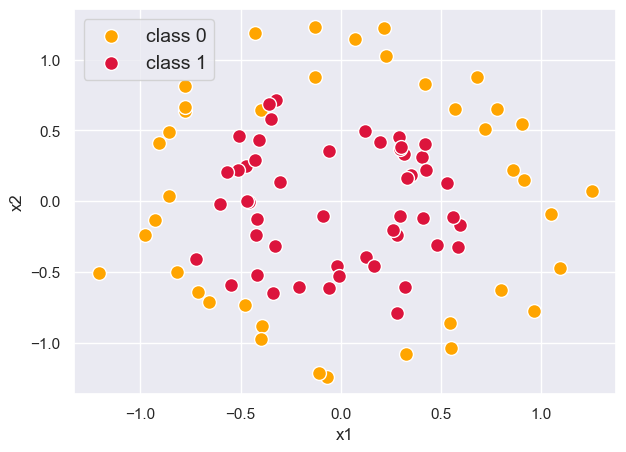

In [13]:
data = datasets.make_circles(
    n_samples=100,
    factor=0.5,
    noise=0.15,
    random_state=0
)

x, y = data[0], data[1]

# Make it imbalanced
idx = np.sort(
    np.append(np.where(y != 0)[0],np.where(y == 0)[0][:-10]    ))

x, y = x[idx], y[idx]

plt.figure(figsize=(7, 5))

plt.scatter(
    x[y == 0, 0],
    x[y == 0, 1],
    c='orange',
    edgecolors='w',
    s=100,
    label='class 0'
)

plt.scatter(
    x[y == 1, 0],
    x[y == 1, 1],
    c='crimson',
    edgecolors='w',
    s=100,
    label='class 1'
)

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(fontsize=14)
plt.show()

In [14]:
c_scale = [[0, "rgb(247, 168, 84)"], [1, "rgb(209, 0, 0)"]]

def create_scatter(x, y, plot_type):
    
    return go.Scatter3d(
                x=x[:, 0], y=x[:, 1], z=y,
                mode="markers",
                marker=dict(
                    size=6,
                    color=y,
                    colorscale=c_scale if plot_type == "pred" else "Blugrn",
                    line=dict(width=4, color="White"),
                ),
            )

def format_plot(fig):
  return fig.update_layout(
      scene=dict(
          xaxis_title="x1", 
          yaxis_title="x2", 
          zaxis_title="y"
      ),
      height=400,
      width=600,
      margin=dict(l=10, r=10, t=40, b=20),
  )

fig = go.Figure()
fig.add_trace(create_scatter(x, y, "pred"))
fig = format_plot(fig)
fig.show()

In [15]:
def create_residual_lines(x, y, pred):
    
    #create the coordinate list for the lines
    x_list, y_list, z_list = [], [], []
    for i in range(len(x)):
        x_list.extend([x[i, 0], x[i, 0], None])
        y_list.extend([x[i, 1], x[i, 1], None])
        z_list.extend([y[i], pred[i], None])

    return go.Scatter3d(x=x_list,   y=y_list, z=z_list, mode='lines',line=dict(color='brown',  width=5))


In [18]:
import numpy as np
import plotly.graph_objects as go


def create_scatter(x, y, name):
    fig = go.Scatter(
        x=x,
        y=y,
        mode="markers",
        name=name
    )
    return fig


def create_residual_lines(x, y, predictions):
    traces = []

    for i in range(len(x)):
        traces.append(
            go.Scatter(
                x=[x[i], x[i]],
                y=[y[i], predictions[i]],
                mode="lines",
                showlegend=False
            )
        )

    return go.Scatter(
        x=np.repeat(x, 2),
        y=np.column_stack((y, predictions)).flatten(),
        mode="lines",
        name="Residuals",
        showlegend=False
    )


def format_plot(fig):
    fig.update_layout(
        title="Actual vs Predicted",
        xaxis_title="X",
        yaxis_title="Y",
        template="plotly_white"
    )
    return fig

In [19]:
def train_and_update(
    x, y, Fm, x1_mesh, x2_mesh, Fm_mesh,
    learning_rate=0.1, print_tree=True
):
    # Step 1: Convert Fm into probability
    p = 1 / (1 + np.exp(-Fm))

    # Step 2: Calculate residuals
    r = y - p

    # Step 3: Train a decision tree on residuals
    tree = DecisionTreeRegressor(
        max_depth=1,
        random_state=0
    )

    tree.fit(x, r)

    # Step 4: Get leaf IDs
    ids = tree.apply(x)

    if print_tree:
        print_tree_structure(tree)

    # Step 5: Prepare mesh data
    x_mesh = np.c_[
        x1_mesh.ravel(),
        x2_mesh.ravel()
    ]

    r_pred_mesh = tree.predict(x_mesh).reshape(
        x1_mesh.shape
    )

    # Step 6: Calculate gamma for each leaf
    for j in np.unique(ids):
        fltr = ids == j

        num = r[fltr].sum()

        den = (
            p[fltr] * (1 - p[fltr])
        ).sum()

        gamma = num / den

        # Update Fm
        Fm[fltr] += learning_rate * gamma

        # Update tree leaf value
        tree.tree_.value[j, 0, 0] = gamma

    # Step 7: Update mesh predictions
    gamma_update_mesh = tree.predict(x_mesh).reshape(
        x1_mesh.shape
    )

    Fm_mesh += learning_rate * gamma_update_mesh

    # Step 8: Convert updated scores to probabilities
    p_mesh = 1 / (1 + np.exp(-Fm_mesh))

    return tree, r, Fm, r_pred_mesh, Fm_mesh

In [20]:
# this function print out tree structures. adapted from https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html
def print_tree_structure(clf):
    
    n_nodes = clf.tree_.node_count
    children_left = clf.tree_.children_left
    children_right = clf.tree_.children_right
    feature = clf.tree_.feature
    threshold = clf.tree_.threshold

    node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
    is_leaves = np.zeros(shape=n_nodes, dtype=bool)
    stack = [(0, 0)]  # start with the root node id (0) and its depth (0)
    while len(stack) > 0:
        # `pop` ensures each node is only visited once
        node_id, depth = stack.pop()
        node_depth[node_id] = depth

        # If the left and right child of a node is not the same we have a split
        # node
        is_split_node = children_left[node_id] != children_right[node_id]
        # If a split node, append left and right children and depth to `stack`
        # so we can loop through them
        if is_split_node:
            stack.append((children_left[node_id], depth + 1))
            stack.append((children_right[node_id], depth + 1))
        else:
            is_leaves[node_id] = True

    print('-'*80)
    print(
        "The binary tree structure has {n} nodes and has "
        "the following tree structure:\n".format(n=n_nodes)
    )
    for i in range(n_nodes):
        if is_leaves[i]:
            print(
                "{space}node={node} is a leaf node.".format(
                    space=node_depth[i] * "\t", node=i
                )
            )
            print(node_depth[i] * '\t', f"prediction: {clf.tree_.value[i, 0, 0]:.1f}")
        else:
            print(
                "{space}node={node} is a split node: "
                "go to node {left} if X[:, {feature}] <= {threshold} "
                "else to node {right}.".format(
                    space=node_depth[i] * "\t",
                    node=i,
                    left=children_left[i],
                    feature=feature[i],
                    threshold=threshold[i],
                    right=children_right[i],
                )
            )
    print('-'*80)

In [21]:
# lect 123 ka code abhi baaki hai 
